In [11]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

results_dir = Path("/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/diffusion_scenario")
csv_files = sorted(results_dir.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {results_dir}")

required_cols = {"scenario", "total_params", "val_l2"}
csv_files

[PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/diffusion_scenario/diffusion_scenario_01_fno_sweep_results.csv'),
 PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/diffusion_scenario/diffusion_scenario_02_fno_sweep_results.csv'),
 PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/diffusion_scenario/diffusion_scenario_03_fno_sweep_results.csv'),
 PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/diffusion_scenario/diffusion_scenario_04_fno_sweep_results.csv'),
 PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/diffusion_scenario/diffusion_scenario_05_fno_sweep_results.csv')]

In [12]:
records = []

for csv_path in csv_files:
    df = pd.read_csv(csv_path)
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"{csv_path.name} is missing required columns: {sorted(missing)}")

    df = df.sort_values("total_params")
    records.append(df[["scenario", "total_params", "val_l2"]])

plot_df = pd.concat(records, ignore_index=True)
plot_df.head()

,scenario,total_params,val_l2
0,scenario_01,44330,0.023354
1,scenario_01,159826,0.022281
2,scenario_01,613538,0.022548
3,scenario_01,2411842,0.018264
4,scenario_01,9571970,0.021078


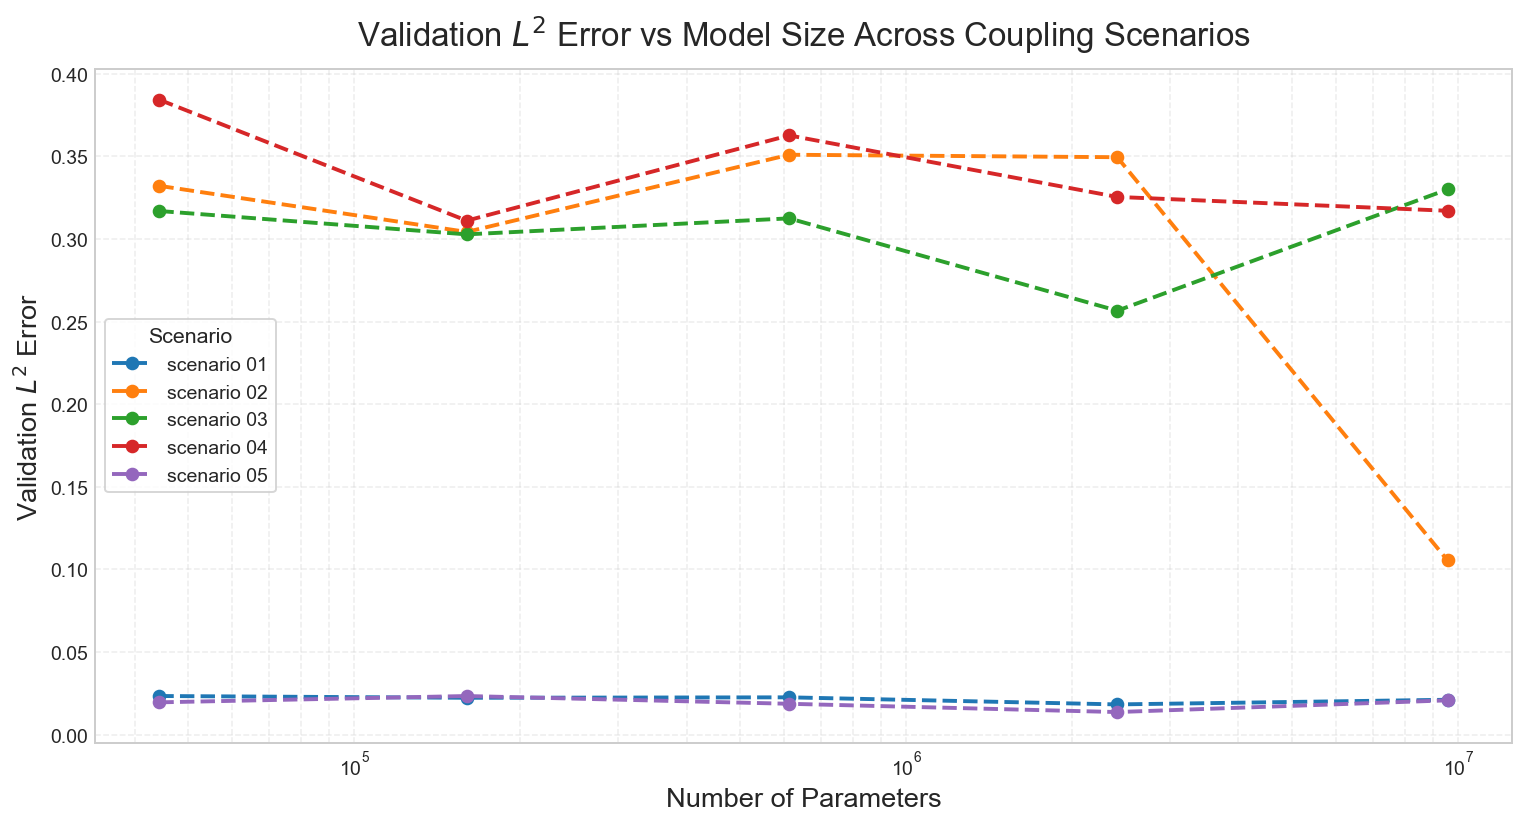

In [13]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(11, 6), dpi=140)

palette = plt.get_cmap("tab10")
scenarios = sorted(plot_df["scenario"].unique())

for idx, scenario in enumerate(scenarios):
    scenario_df = plot_df[plot_df["scenario"] == scenario].sort_values("total_params")
    ax.plot(
        scenario_df["total_params"],
        scenario_df["val_l2"],
        marker="o",
        linestyle="--",
        linewidth=2,
        markersize=6,
        color=palette(idx),
        label=scenario.replace("_", " "),
    )

ax.set_xscale("log")
ax.set_xlabel("Number of Parameters", fontsize=14)
ax.set_ylabel(r"Validation $L^2$ Error", fontsize=14)
ax.set_title(r"Validation $L^2$ Error vs Model Size Across Coupling Scenarios", fontsize=17, pad=12)
ax.grid(True, which="both", linestyle="--", alpha=0.35)
ax.legend(title="Scenario", fontsize=10, title_fontsize=11, frameon=True)

plt.tight_layout()
plt.show()

In [14]:
summary = (
    plot_df.sort_values(["scenario", "val_l2"])
    .groupby("scenario", as_index=False)
    .first()[["scenario", "total_params", "val_l2"]]
    .rename(columns={"total_params": "best_total_params", "val_l2": "best_val_l2"})
)
summary

,scenario,best_total_params,best_val_l2
0,scenario_01,2411842,0.018264
1,scenario_02,9571970,0.105422
2,scenario_03,2411842,0.256617
3,scenario_04,159826,0.311116
4,scenario_05,2411842,0.013641
